In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

# Data Loading and Pre-processing

In [ ]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (13954, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13954 entries, 0 to 13953
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    13954 non-null  int64  
 1   V1      13954 non-null  float64
 2   V2      13954 non-null  float64
 3   V3      13954 non-null  float64
 4   V4      13954 non-null  float64
 5   V5      13954 non-null  float64
 6   V6      13954 non-null  float64
 7   V7      13954 non-null  float64
 8   V8      13954 non-null  float64
 9   V9      13954 non-null  float64
 10  V10     13954 non-null  float64
 11  V11     13954 non-null  float64
 12  V12     13954 non-null  float64
 13  V13     13954 non-null  float64
 14  V14     13954 non-null  float64
 15  V15     13954 non-null  float64
 16  V16     13954 non-null  float64
 17  V17     13954 non-null  float64
 18  V18     13954 non-null  float64
 19  V19     13954 non-null  float64
 20  V20     13954 non-null  float64
 21  V21     

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,13954.000000,13954.000000,13954.000000,13954.000000,13954.000000,13954.000000,13954.000000,13954.000000,13954.000000,13954.000000,...,13954.000000,13954.000000,13954.000000,13954.000000,13954.000000,13954.000000,13954.000000,13954.000000,13953.000000,13953.000000
mean,10121.161817,-0.235676,0.284287,0.846047,0.302775,-0.118730,0.128013,-0.157297,-0.016148,0.989827,...,-0.068037,-0.157471,-0.035585,0.011158,0.117019,0.035544,0.012787,0.002122,63.882442,0.004013
std,7739.625811,1.720315,1.394804,1.561376,1.500595,1.289494,1.320395,1.238583,1.262024,1.214044,...,0.873942,0.621845,0.499807,0.587225,0.427953,0.558290,0.399550,0.255710,177.887021,0.063227
min,0.000000,-27.670569,-34.607649,-24.667741,-4.657545,-32.092129,-23.496714,-26.548144,-23.632502,-7.175097,...,-11.468435,-8.593642,-19.254328,-2.512377,-4.781606,-1.338556,-7.976100,-3.575312,0.000000,0.000000
25%,2984.250000,-0.969786,-0.282728,0.407297,-0.623141,-0.717155,-0.624025,-0.616307,-0.182270,0.288101,...,-0.271778,-0.549723,-0.173807,-0.339656,-0.135887,-0.374596,-0.076862,-0.014869,5.490000,0.000000
50%,9086.500000,-0.319439,0.252904,0.960978,0.220104,-0.191627,-0.144198,-0.111960,0.016945,0.971414,...,-0.132304,-0.122777,-0.045041,0.060208,0.155162,-0.035825,-0.000950,0.016238,15.690000,0.000000
75%,17103.500000,1.162662,0.884741,1.607031,1.198942,0.351255,0.508494,0.421830,0.265736,1.654184,...,0.018677,0.228997,0.069750,0.392734,0.393032,0.375271,0.098516,0.072497,52.150000,0.000000
max,24759.000000,1.960497,10.558600,4.101716,11.927512,34.099309,21.393069,34.303177,10.535558,10.392889,...,22.614889,4.534454,13.876221,3.200201,5.525093,3.517346,8.254376,4.860769,7712.430000,1.000000


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df[df.isnull().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
13953,24759,-6.917152,5.854171,-1.652458,-1.488884,-0.833891,-0.344418,0.393789,0.379968,6.133597,...,-1.404681,-1.124694,0.174333,-0.528234,0.990685,-0.035875,1.071374,-0.168831,NaN,NaN


In [ ]:
df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 53


In [ ]:
df = df.drop_duplicates()

print(df.shape)

(13900, 31)


# EDA

Class
0.0    13844
1.0       56
Name: count, dtype: int64


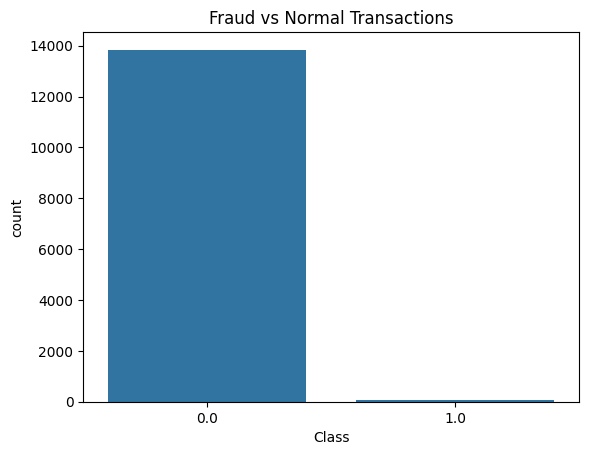

In [ ]:
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [ ]:
fraud_percentage = (df['Class'].value_counts(normalize=True))*100

print(fraud_percentage)

Class
0.0    99.597122
1.0     0.402878
Name: proportion, dtype: float64


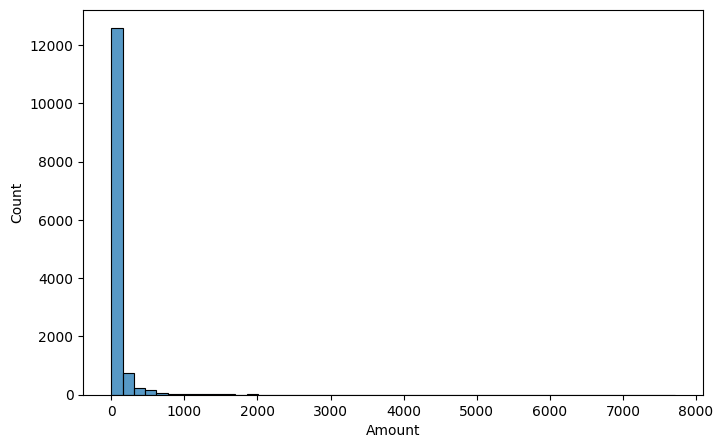

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Amount'],bins=50)

plt.show()

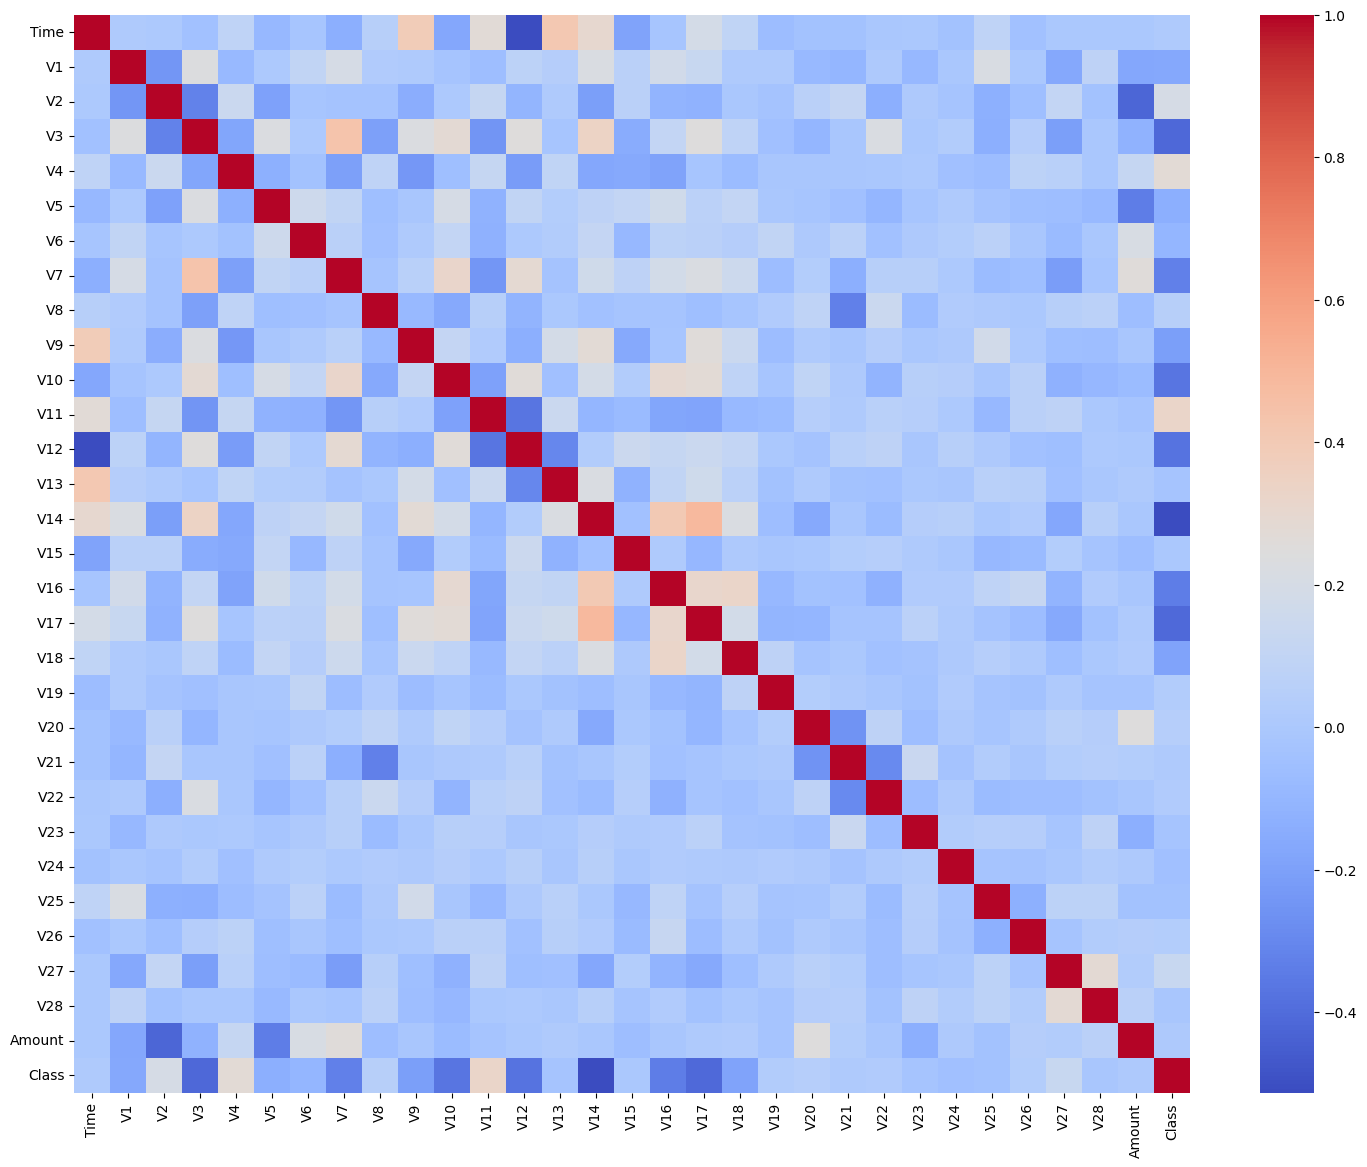

In [46]:
plt.figure(figsize=(18,14))

sns.heatmap(df.corr(),cmap="coolwarm")

plt.show()

In [48]:
fig =plt.gcf()
fig.savefig("heatmap.png", dpi=300, bbox_inches="tight")
from google.colab import files
files.download("heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

# Feature Scaling



In [ ]:
X = df.drop('Class',axis=1)

y = df['Class']

In [ ]:
scaler = StandardScaler()

X[['Time','Amount']] = scaler.fit_transform(
    X[['Time','Amount']]
)

# Train-Test Split and SMOTE

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote,y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train.shape)

print(X_train_smote.shape)

(11120, 30)
(22150, 30)


In [ ]:
print(X_train.shape)
print(X_train_smote.shape)
print(y_train_smote.value_counts())

rf = RandomForestClassifier(
    random_state=42
)

(11120, 30)
(22150, 30)
Class
0.0    11075
1.0    11075
Name: count, dtype: int64


In [ ]:
print(train.shape)

(22150, 31)


In [ ]:
X_train_small = train.drop("Class", axis=1)
y_train_small = train["Class"]

# Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000)

In [ ]:
lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(y_test,lr_pred))

print("Accuracy :",accuracy_score(y_test,lr_pred))

print("Precision :",precision_score(y_test,lr_pred))

print("Recall :",recall_score(y_test,lr_pred))

print("F1 Score :",f1_score(y_test,lr_pred))

print("ROC AUC :",roc_auc_score(y_test,lr_prob))

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      2769
         1.0       0.23      0.91      0.37        11

    accuracy                           0.99      2780
   macro avg       0.62      0.95      0.68      2780
weighted avg       1.00      0.99      0.99      2780

Accuracy : 0.9877697841726619
Precision : 0.23255813953488372
Recall : 0.9090909090909091
F1 Score : 0.37037037037037035
ROC AUC : 0.9977018286877442


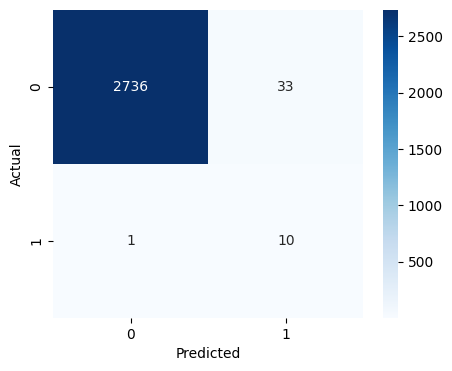

In [ ]:
cm = confusion_matrix(y_test,lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,

            annot=True,

            fmt='d',

            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_small, y_train_small)

RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [ ]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(y_test,rf_pred))

print("Accuracy :",accuracy_score(y_test,rf_pred))

print("Precision :",precision_score(y_test,rf_pred))

print("Recall :",recall_score(y_test,rf_pred))

print("F1 Score :",f1_score(y_test,rf_pred))

print("ROC AUC :",roc_auc_score(y_test,rf_prob))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2769
         1.0       1.00      0.91      0.95        11

    accuracy                           1.00      2780
   macro avg       1.00      0.95      0.98      2780
weighted avg       1.00      1.00      1.00      2780

Accuracy : 0.9996402877697842
Precision : 1.0
Recall : 0.9090909090909091
F1 Score : 0.9523809523809523
ROC AUC : 0.9998522604156408


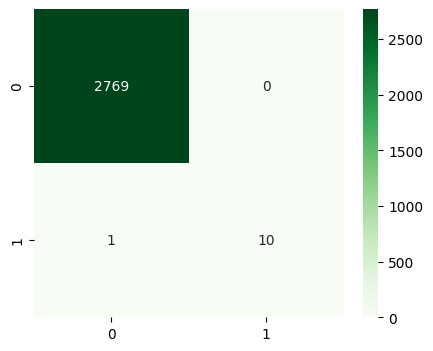

In [ ]:
cm = confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,

            annot=True,

            fmt='d',

            cmap='Greens')

plt.show()

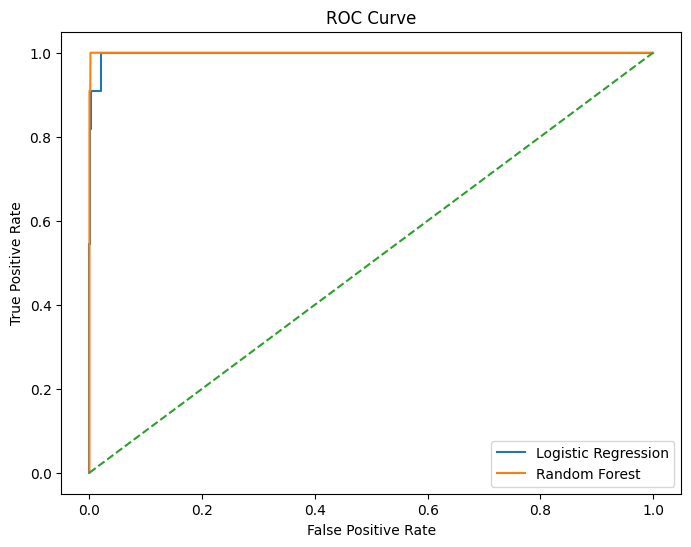

In [ ]:
fpr_lr,tpr_lr,_ = roc_curve(y_test,lr_prob)

fpr_rf,tpr_rf,_ = roc_curve(y_test,rf_prob)

plt.figure(figsize=(8,6))

plt.plot(

    fpr_lr,

    tpr_lr,

    label="Logistic Regression"

)

plt.plot(

    fpr_rf,

    tpr_rf,

    label="Random Forest"

)

plt.plot(

    [0,1],

    [0,1],

    '--'

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

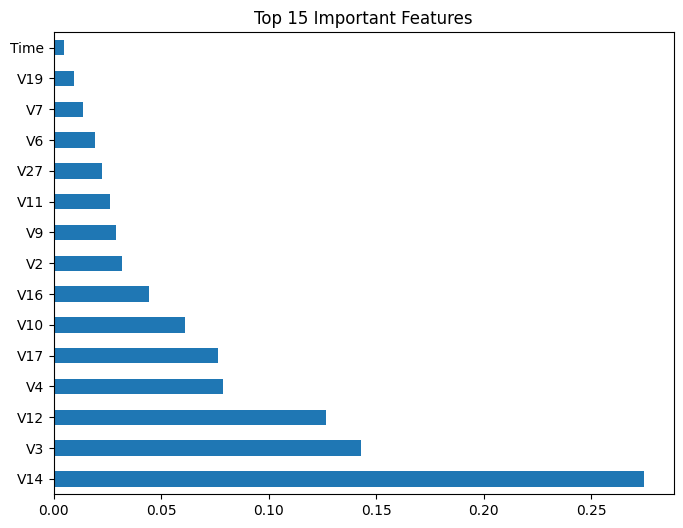

In [ ]:
importance = pd.Series(

    rf.feature_importances_,

    index=X.columns

)

importance.sort_values(

    ascending=False

).head(15).plot(

    kind='barh',

    figsize=(8,6)

)

plt.title("Top 15 Important Features")

plt.show()

# Hyper parameter tuning

In [ ]:
params = {
    'n_estimators': [100],
    'max_depth': [10],
    'min_samples_split': [2]
}

In [ ]:
grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    params,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1

)

In [ ]:
grid.fit(
    X_train_small,
    y_train_small
)

print(grid.best_params_)

print(grid.best_score_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
0.999999959235461


# Best Model Train

In [ ]:
best_rf = grid.best_estimator_

best_rf.fit(

    X_train_smote,

    y_train_smote
)

RandomForestClassifier(max_depth=10, random_state=42)

In [ ]:
best_rf = grid.best_estimator_

best_rf.fit(

    X_train_smote,

    y_train_smote
)

RandomForestClassifier(max_depth=10, random_state=42)

# Final Evaluation

In [ ]:
print(classification_report(y_test,rf_pred))

print("Accuracy :",accuracy_score(y_test,rf_pred))

print("Precision :",precision_score(y_test,rf_pred))

print("Recall :",recall_score(y_test,rf_pred))

print("F1 Score :",f1_score(y_test,rf_pred))

print("ROC AUC :",roc_auc_score(y_test,rf_prob))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2769
         1.0       1.00      0.91      0.95        11

    accuracy                           1.00      2780
   macro avg       1.00      0.95      0.98      2780
weighted avg       1.00      1.00      1.00      2780

Accuracy : 0.9996402877697842
Precision : 1.0
Recall : 0.9090909090909091
F1 Score : 0.9523809523809523
ROC AUC : 0.9998522604156408


# Model Camparison



In [ ]:
comparison = pd.DataFrame({

'Model':['Logistic Regression','Random Forest'],

'Accuracy':[

accuracy_score(y_test,lr_pred),

accuracy_score(y_test,rf_pred)

],

'Precision':[

precision_score(y_test,lr_pred),

precision_score(y_test,rf_pred)

],

'Recall':[

recall_score(y_test,lr_pred),

recall_score(y_test,rf_pred)

],

'F1 Score':[

f1_score(y_test,lr_pred),

f1_score(y_test,rf_pred)

],

'ROC AUC':[

roc_auc_score(y_test,lr_prob),

roc_auc_score(y_test,rf_prob)

]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.98777,0.232558,0.909091,0.370370,0.997702
1,Random Forest,0.99964,1.000000,0.909091,0.952381,0.999852


# Conslusion

In [ ]:
print("""
Conclusion

1. The dataset was explored and cleaned.
2. Duplicate records were removed.
3. Feature scaling was applied to Time and Amount.
4. SMOTE successfully balanced the minority class.
5. Logistic Regression and Random Forest models were trained.
6. Hyperparameter tuning was performed using GridSearchCV.
7. Models were evaluated using Precision, Recall, F1-Score and ROC-AUC.
8. Random Forest achieved the best overall performance for fraud detection.
""")


Conclusion

1. The dataset was explored and cleaned.
2. Duplicate records were removed.
3. Feature scaling was applied to Time and Amount.
4. SMOTE successfully balanced the minority class.
5. Logistic Regression and Random Forest models were trained.
6. Hyperparameter tuning was performed using GridSearchCV.
7. Models were evaluated using Precision, Recall, F1-Score and ROC-AUC.
8. Random Forest achieved the best overall performance for fraud detection.

